# Notebook 07 — Feature Engineering y Dataset para Modelado

**Proyecto de Grado — Maestria en Ciencia de Datos**
**Pontificia Universidad Javeriana Cali — Grupo 8**
**Autores:** Laura Garcia Salamanca, Daniel Sebastian Rosero Usama, Juan Villalobos Mora

---

## Objetivo
Preparar el dataset normalizado y las clases de acceso dinamico a ventanas
temporales para el entrenamiento del modelo Informer y los modelos de
referencia (LSTM y GRU).

## Estrategia de memoria

Construir todos los arrays de ventanas de forma estatica es inviable:
el split de entrenamiento tiene 931,103 ventanas de shape (288, 18),
lo que equivale a ~19 GB en float32. Ningun entorno Colab gratuito
puede sostener eso.

La solucion es un **Dataset de PyTorch de indexacion dinamica**: el array
normalizado completo (91 MB) se mantiene en RAM, y cada ventana se
construye en el momento en que el DataLoader la solicita. Esto es
exactamente como funciona el repositorio oficial del Informer y la
mayoria de implementaciones profesionales de Transformers para series
temporales.

## Configuracion
  seq_len   = 288  pasos = 24 horas de contexto
  label_len = 144  pasos = 12 horas (ventana de inicio del decodificador)
  pred_len  = 12 / 36 / 72  pasos = 1h / 3h / 6h de prediccion

## Contenido
1. Carga y verificacion
2. Seleccion y transformacion de variables
3. Normalizacion y particion temporal
4. Clase InformerDataset (Dataset dinamico)
5. Verificacion y prueba del Dataset
6. Guardado de artefactos
7. Visualizaciones
8. Resumen


---
## Cambios de la revision (septiembre de 2026)

**Embargo en las fronteras.** La particion sigue siendo cronologica, pero ahora descarta 576
pasos, dos dias completos, entre entrenamiento y validacion y entre validacion y prueba. Con ese
margen la ventana de contexto de la primera muestra de evaluacion empieza despues del ultimo
instante que el modelo vio durante el entrenamiento. Cuesta el 0.09 % de la serie.

**Marcas de tiempo.** Se guarda `timestamps.npy` junto a los demas artefactos. El cuaderno 06 lo
necesita para anular la prediccion fuera de la franja diurna y para agrupar las metricas por
trimestre.

**Antes de ejecutar.** Requiere que el cuaderno 02 revisado se haya ejecutado ya. Si el
experimento de ocultamiento del cuaderno 09 selecciono una tecnica de imputacion distinta de la
interpolacion, cambia el archivo que se carga en la celda de rutas.
---

In [ ]:
# 0. Importaciones
!pip install pandas numpy matplotlib seaborn scikit-learn torch --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import subprocess
import os
import pickle
import gc
import warnings
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
import torch
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# El estilo de las figuras (paleta y tamanos de letra) se define en la celda
# siguiente, la celda de estilo, para que sea identico en los 11 cuadernos.

# Configuracion de ventanas (en intervalos de 5 min)
SEQ_LEN   = 288   # 24 horas de contexto
LABEL_LEN = 144   # 12 horas — inicio del decodificador Informer
PRED_LENS = {'1h': 12, '3h': 36, '6h': 72}

# Particion temporal
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

print('Librerias importadas:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
print(f'SEQ_LEN={SEQ_LEN} | LABEL_LEN={LABEL_LEN}')
for nombre, pl in PRED_LENS.items():
    print(f'  pred_len {nombre}: {pl} pasos = {pl*5/60:.1f}h')

Librerias importadas: 2026-09-09 21:55:06
SEQ_LEN=288 | LABEL_LEN=144
  pred_len 1h: 12 pasos = 1.0h
  pred_len 3h: 36 pasos = 3.0h
  pred_len 6h: 72 pasos = 6.0h


### Estilo unico de figuras

Esta celda fija la **paleta de colores** y los **tamanos de letra** de todas las figuras del cuaderno. Es la misma celda en los once cuadernos, de modo que cualquier figura del trabajo de grado sale con el mismo aspecto.


In [ ]:
# @@ESTILO_TG@@  (marca unica: no editar esta linea)
# =============================================================================
#  ESTILO UNICO DE FIGURAS DEL TRABAJO DE GRADO
#  Esta celda define la paleta y la tipografia de TODAS las figuras.
#  Es identica en los 11 cuadernos: cambiarla aqui cambia solo este cuaderno,
#  por eso si se modifica hay que modificarla en todos.
#
#  Paleta categorica anclada en el azul. Validada con el verificador de
#  accesibilidad de color (separacion OKLab bajo protanopia y deuteranopia,
#  piso de croma, banda de luminosidad y contraste contra fondo blanco):
#  todos los pares de colores pasan, no solo los contiguos.
# =============================================================================
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler
try:
    import seaborn as sns
except Exception:
    sns = None

# --- 1. Paleta categorica (orden FIJO: la ranura 1 es siempre la serie principal)
C_AZUL    = '#0C60A3'   # ranura 1 - serie principal / observado / T1 / V1
C_AMBAR   = '#D4771A'   # ranura 2 - segunda serie / modelo / T2 / V2
C_CELESTE = '#269AE6'   # ranura 3 - tercera serie / T3 / V3
C_TEJA    = '#963E35'   # ranura 4 - cuarta serie
C_VERDEAZ = '#0D8F73'   # ranura 5 - quinta serie
PALETA_TG = [C_AZUL, C_AMBAR, C_CELESTE, C_TEJA, C_VERDEAZ]

# --- 2. Tonos de apoyo de la rampa azul (rellenos, bandas, sombreados)
C_AZUL_CLARO  = '#81B4EA'
C_AZUL_MEDIO  = '#5A9BDC'
C_AZUL_OSCURO = '#0A3765'

# --- 3. Tinta neutra: texto, ejes, lineas de referencia. NUNCA es una serie.
C_TEXTO      = '#1A1A1A'
C_GRIS       = '#6E6E6E'
C_GRIS_CLARO = '#C9C9C9'

# --- 4. Mapas de color continuos
#   'tg_azul' : secuencial de un solo tono, claro -> oscuro (magnitudes)
#   'tg_div'  : divergente azul <-> teja con gris neutro en el centro
#               (mantiene la lectura de 'RdBu_r': negativo azul, positivo calido)
_SECUENCIAL = ['#F4F9FF', '#D8E8FA', '#B4D2F4', '#81B4EA', '#5A9BDC',
               '#3581C9', '#1667AC', '#0B4E89', '#0A3765']
_DIVERGENTE = ['#0A3765', '#1667AC', '#5A9BDC', '#AFCEEC', '#F2F1EF',
               '#EFC9AC', '#DC9A5A', '#B4642C', '#7E3A2C']
CMAP_SEC = LinearSegmentedColormap.from_list('tg_azul', _SECUENCIAL)
CMAP_DIV = LinearSegmentedColormap.from_list('tg_div',  _DIVERGENTE)

def _registrar_cmap(cm_obj):
    """Registra el mapa por nombre para poder usar cmap='tg_azul'."""
    try:
        mpl.colormaps.register(cm_obj, force=True)          # matplotlib >= 3.6
    except Exception:
        try:
            mpl.cm.register_cmap(cmap=cm_obj)               # matplotlib antiguo
        except Exception:
            pass

for _c in (CMAP_SEC, CMAP_DIV):
    _registrar_cmap(_c)

def escala_azul(n, ini=0.375, fin=1.0):
    """n colores tomados de la rampa azul. Para variables ORDENADAS (anios,
    meses, horizontes): el orden se lee en el tono, de claro a oscuro."""
    if n <= 1:
        return [C_AZUL]
    paso = (fin - ini) / (n - 1)
    return [CMAP_SEC(ini + i * paso) for i in range(n)]

# --- 6. Eje X de fechas legible ----------------------------------------------
import matplotlib.dates as mdates

def eje_fechas(ax):
    """Ajusta el eje X de fechas al rango real de la serie: anios cuando abarca
    anios, meses cuando abarca meses. Evita que se repita la misma etiqueta
    ('2023 2023 2023 ...') cuando el periodo es corto."""
    loc = mdates.AutoDateLocator(minticks=4, maxticks=9)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    return ax

# --- 7. Trazo por serie: si dos curvas se superponen, el trazo las separa -----
ESTILOS_TG = ['-', '--', ':', '-.', (0, (5, 1, 1, 1))]
TRAZO = {'T1': '-', 'T2': '--', 'T3': ':',
         'V1': '-', 'V2': '--', 'V3': ':'}

# --- 5. Tipografia: tamanos grandes para que la figura se lea en el PDF impreso
TAM_BASE = 13          # texto general dentro de la figura
TAM_EJE  = 14          # etiquetas de los ejes X e Y
TAM_TICK = 12          # numeros de los ejes
TAM_TIT  = 14.5        # titulo del panel
TAM_LEY  = 12          # leyenda

plt.rcParams.update({
    # --- color
    'axes.prop_cycle'   : cycler(color=PALETA_TG),
    'image.cmap'        : 'tg_azul',
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'savefig.facecolor' : 'white',
    # --- tipografia (lo que pidio la revision: ejes y etiquetas legibles)
    'font.family'       : 'sans-serif',
    'font.size'         : TAM_BASE,
    'axes.titlesize'    : TAM_TIT,
    'axes.labelsize'    : TAM_EJE,
    'axes.titleweight'  : 'bold',
    'axes.labelweight'  : 'normal',
    'xtick.labelsize'   : TAM_TICK,
    'ytick.labelsize'   : TAM_TICK,
    'legend.fontsize'   : TAM_LEY,
    'legend.title_fontsize': TAM_LEY,
    'figure.titlesize'  : TAM_TIT + 1.5,
    # --- trazos y ejes discretos
    'lines.linewidth'   : 1.8,
    'lines.markersize'  : 5.5,
    'axes.linewidth'    : 0.9,
    'axes.edgecolor'    : '#8A8A8A',
    'axes.labelcolor'   : C_TEXTO,
    'text.color'        : C_TEXTO,
    'xtick.color'       : '#8A8A8A',
    'ytick.color'       : '#8A8A8A',
    'xtick.labelcolor'  : C_TEXTO,
    'ytick.labelcolor'  : C_TEXTO,
    'xtick.major.width' : 0.9,
    'ytick.major.width' : 0.9,
    'grid.color'        : C_GRIS_CLARO,
    'grid.linewidth'    : 0.7,
    'grid.alpha'        : 0.55,
    'legend.frameon'    : True,
    'legend.framealpha' : 0.92,
    'legend.edgecolor'  : '#C9C9C9',
    # --- exportacion para Overleaf: el texto viaja como texto dentro del PDF
    'figure.dpi'        : 110,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
    'svg.fonttype'      : 'path',
})

if sns is not None:
    sns.set_palette(PALETA_TG)

print('Estilo de figuras aplicado.')
print(f'  Paleta categorica: {", ".join(PALETA_TG)}')
print(f'  Mapas continuos:   tg_azul (secuencial), tg_div (divergente)')
print(f'  Tamanos: ejes {TAM_EJE} pt, numeros {TAM_TICK} pt, leyenda {TAM_LEY} pt')


Estilo de figuras aplicado.
  Paleta categorica: #0C60A3, #D4771A, #269AE6, #963E35, #0D8F73
  Mapas continuos:   tg_azul (secuencial), tg_div (divergente)
  Tamanos: ejes 14 pt, numeros 12 pt, leyenda 12 pt


In [ ]:
# @@RUTAS_TG@@  (marca unica: no editar esta linea)
# =============================================================================
#  DONDE VIVE EL PROYECTO
#
#  En el Drive hay mas de una copia del proyecto: la del semestre anterior y la
#  actual. Antes cada cuaderno buscaba un archivo de datos por todo el Drive y
#  se quedaba con el PRIMERO que aparecia, que no siempre era el de la carpeta
#  correcta; por eso 'figuras', 'figuras_PDF' y 'figuras_SVG' se crearon en la
#  carpeta vieja.
#
#  Ahora la carpeta del proyecto se decide UNA sola vez y de forma explicita:
#  es la carpeta cuyo nombre esta en NOMBRE_CARPETA y cuya ruta contiene
#  CARPETA_PROYECTO. TODO lo que el cuaderno escriba va ahi.
#
#  Si algun dia mueves el proyecto (por ejemplo a 'Proyecto Aplicado IV'),
#  cambias UNA linea: CARPETA_PROYECTO. Y la cambias en los once cuadernos.
# =============================================================================
import os
import subprocess

CARPETA_PROYECTO = 'Proyecto Aplicado III'      # <-- la carpeta actual del semestre
NOMBRE_CARPETA   = 'Codigos Trabajo de Grado'   # <-- nombre de la carpeta de codigo
RAIZ_DRIVE       = '/content/drive/MyDrive'

# Rutas que nunca se usan como carpeta del proyecto, aunque coincidan de nombre.
EXCLUIR_RUTAS = ['/anterior/', '/.Trash', '/.shortcut-targets-by-id/',
                 '/copia de ', '/copy of ']


def _montar_drive():
    try:
        from google.colab import drive
    except Exception:
        return
    if not os.path.isdir(RAIZ_DRIVE):
        drive.mount('/content/drive')
    else:
        print('Drive ya montado.')


def _find(patron, tipo='f', maxdepth=None, raiz=RAIZ_DRIVE, timeout=300):
    cmd = ['find', raiz]
    if maxdepth is not None:
        cmd += ['-maxdepth', str(maxdepth)]
    cmd += ['-type', tipo, '-name', patron]
    try:
        res = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
    except Exception:
        return []
    return [r for r in res.stdout.strip().split('\n') if r]


def _excluida(ruta):
    r = ruta.lower()
    return any(x.lower() in r for x in EXCLUIR_RUTAS)


def localizar_proyecto():
    """Devuelve la carpeta del proyecto. Falla con un mensaje claro si no la
    encuentra o si encuentra mas de una: nunca elige a ciegas."""
    _montar_drive()

    candidatas = _find(NOMBRE_CARPETA, tipo='d', maxdepth=8)
    if not candidatas:
        candidatas = _find(NOMBRE_CARPETA, tipo='d')
    # Segunda pista: cualquier carpeta que contenga los cuadernos de la cadena.
    for nb in _find('0*_*REVISADO.ipynb', tipo='f', maxdepth=9):
        d = os.path.dirname(nb)
        if d not in candidatas:
            candidatas.append(d)

    validas   = [c for c in candidatas if CARPETA_PROYECTO in c and not _excluida(c)]
    descartes = [c for c in candidatas if c not in validas]

    if len(validas) == 1:
        print(f'Carpeta del proyecto: {validas[0]}')
        if descartes:
            print(f'  ({len(descartes)} carpeta(s) descartada(s) por no estar en '
                  f'"{CARPETA_PROYECTO}")')
        return validas[0]

    print('\n' + '=' * 78)
    print('NO SE PUDO DECIDIR LA CARPETA DEL PROYECTO')
    print('=' * 78)
    print(f'  Se busca:  una carpeta "{NOMBRE_CARPETA}" cuya ruta contenga '
          f'"{CARPETA_PROYECTO}"')
    print(f'  Encontradas: {len(candidatas)}')
    for c in candidatas:
        marca = 'SIRVE     ' if c in validas else 'descartada'
        print(f'    [{marca}] {c}')
    print()
    if not validas:
        print('  Que hacer: comprueba el nombre exacto de la carpeta en Drive y ajusta')
        print('  arriba CARPETA_PROYECTO o NOMBRE_CARPETA. Si moviste el proyecto,')
        print('  recuerda cambiarlo en los once cuadernos.')
    else:
        print('  Hay varias carpetas que sirven. Escribe arriba una CARPETA_PROYECTO')
        print('  mas especifica, por ejemplo la ruta completa desde MyDrive.')
    print('=' * 78 + '\n')
    raise FileNotFoundError(
        f'No hay exactamente una carpeta "{NOMBRE_CARPETA}" bajo "{CARPETA_PROYECTO}".')


# --- La carpeta del proyecto y todo lo que cuelga de ella --------------------
RUTA_BASE     = localizar_proyecto()
RUTA_DATOS    = os.path.join(RUTA_BASE, 'datos')
RUTA_ARRAYS   = os.path.join(RUTA_DATOS, 'arrays')
RUTA_MODELOS  = os.path.join(RUTA_BASE, 'modelos')
RUTA_RES      = os.path.join(RUTA_BASE, 'resultados')
RUTA_FIGS     = os.path.join(RUTA_BASE, 'figuras')       # PNG
RUTA_FIGS_SVG = os.path.join(RUTA_BASE, 'figuras_SVG')   # SVG
RUTA_FIGS_PDF = os.path.join(RUTA_BASE, 'figuras_PDF')   # PDF, el de Overleaf

for _d in (RUTA_DATOS, RUTA_ARRAYS, RUTA_MODELOS, RUTA_RES,
           RUTA_FIGS, RUTA_FIGS_SVG, RUTA_FIGS_PDF):
    os.makedirs(_d, exist_ok=True)


def archivo_de_datos(nombre, obligatorio=True, pista=''):
    """Localiza un archivo de ENTRADA.

    Primero lo busca dentro de la carpeta del proyecto. Solo si no esta lo busca
    en el resto del Drive, y en ese caso avisa en grande: significa que ese
    archivo se quedo en la carpeta vieja y conviene copiarlo.
    Lo que el cuaderno ESCRIBE nunca sale de la carpeta del proyecto.
    """
    for sub in ('datos', os.path.join('datos', 'arrays'), '', 'resultados', 'modelos'):
        cand = os.path.join(RUTA_BASE, sub, nombre) if sub else os.path.join(RUTA_BASE, nombre)
        if os.path.exists(cand):
            return cand

    fuera = _find(nombre, tipo='f')
    if fuera:
        fuera.sort(key=lambda r: os.path.getmtime(r), reverse=True)
        elegido = fuera[0]
        print('\n' + '!' * 78)
        print(f'AVISO: "{nombre}" no esta en la carpeta del {CARPETA_PROYECTO}.')
        print(f'  Se leera de: {elegido}')
        print(f'  Copialo a  : {RUTA_DATOS}')
        print('  Mientras siga en dos sitios, corres el riesgo de leer una version vieja.')
        print('!' * 78 + '\n')
        return elegido

    if obligatorio:
        raise FileNotFoundError(
            f'No se encontro "{nombre}" ni en la carpeta del proyecto ni en el resto '
            f'del Drive.\n  Carpeta del proyecto: {RUTA_BASE}\n  {pista}')
    return None


print(f'  datos      : {RUTA_DATOS}')
print(f'  figuras    : {RUTA_FIGS} (+ _SVG y _PDF)')
print(f'  modelos    : {RUTA_MODELOS}')
print(f'  resultados : {RUTA_RES}')

# --- Entradas propias de este cuaderno ---------------------------------------
# El conjunto de entrada lo decide el cuaderno 09 y lo deja escrito en
# 'tecnica_imputacion.txt'. Si no existe, se usa la interpolacion y se avisa.
_ruta_tec = os.path.join(RUTA_DATOS, 'tecnica_imputacion.txt')
if os.path.exists(_ruta_tec):
    with open(_ruta_tec, 'r', encoding='utf-8') as _f:
        TECNICA = _f.read().strip()
    print(f'Conjunto de entrada: dataset_final_{TECNICA}.csv (decidido en el 09).')
else:
    TECNICA = 'interpolacion'
    print('AVISO: sin tecnica_imputacion.txt; se usa la interpolacion.')
RUTA_T1 = archivo_de_datos(f'dataset_final_{TECNICA}.csv',
                          pista='Lo genera el cuaderno 02.')


Mounted at /content/drive
Carpeta del proyecto: /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado
  datos      : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/datos
  figuras    : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras (+ _SVG y _PDF)
  modelos    : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/modelos
  resultados : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/resultados
Conjunto de entrada: dataset_final_kalman.csv (decidido en el 09).


### Figuras en PNG, SVG y PDF

**Añadido en la revisión.** Todas las figuras de este cuaderno se guardan ahora en los tres
formatos, con el mismo nombre y en tres carpetas paralelas: `figuras/` para el PNG,
`figuras_SVG/` para el vectorial editable y `figuras_PDF/` para el que se incluye en Overleaf.

En LaTeX se incluye sin extensión, y así el compilador elige el formato adecuado:

```latex
\includegraphics[width=\linewidth]{figuras_PDF/fig_01b_distribucion}
```

In [ ]:
# --- Guardado de figuras en los tres formatos ----------------------------
#
# El documento se compila en Overleaf, que incluye las figuras en PDF, pero
# conviene tener tambien el SVG (editable) y el PNG (vista rapida y para
# presentaciones). Antes cada cuaderno guardaba en un formato distinto: unos en
# SVG, otros en PDF, otros en PNG. Ahora todos usan esta funcion y producen los
# tres, con el mismo nombre, en tres carpetas paralelas:
#
#   figuras/       nombre.png   300 ppp
#   figuras_SVG/   nombre.svg   vectorial editable
#   figuras_PDF/   nombre.pdf   el que se incluye en LaTeX
#
# En LaTeX basta con \includegraphics{figuras_PDF/nombre} sin extension.
import os
import matplotlib.pyplot as plt

FORMATOS_FIGURA = (
    ('RUTA_FIGS',     'png', {'dpi': 300}),
    ('RUTA_FIGS_SVG', 'svg', {}),
    ('RUTA_FIGS_PDF', 'pdf', {}),
)


def guardar_figura(fig, nombre, verbose=True):
    """Guarda la figura en PNG, SVG y PDF. 'nombre' va SIN extension."""
    if fig is None:
        fig = plt.gcf()
    base = os.path.splitext(os.path.basename(str(nombre)))[0]
    rutas = []
    for var, ext, extra in FORMATOS_FIGURA:
        carpeta = globals().get(var)
        if carpeta is None:
            continue
        os.makedirs(carpeta, exist_ok=True)
        ruta = os.path.join(carpeta, f'{base}.{ext}')
        fig.savefig(ruta, bbox_inches='tight', **extra)
        rutas.append(ruta)
    if verbose:
        print(f'  Figura guardada: {base}.png, .svg y .pdf')
    return rutas


print('Funcion guardar_figura lista: cada figura se guarda en PNG, SVG y PDF.')
for _v in ('RUTA_FIGS', 'RUTA_FIGS_SVG', 'RUTA_FIGS_PDF'):
    print(f'  {_v:<14} {globals().get(_v)}')

Funcion guardar_figura lista: cada figura se guarda en PNG, SVG y PDF.
  RUTA_FIGS      /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras
  RUTA_FIGS_SVG  /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras_SVG
  RUTA_FIGS_PDF  /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras_PDF


In [ ]:
# 1.1 Carga
print('Cargando dataset T1...')
df = pd.read_csv(RUTA_T1, index_col='timestamp', parse_dates=True)
print(f'Registros : {len(df):,} | Variables : {df.shape[1]}')
print(f'Periodo   : {df.index.min()} -> {df.index.max()}')
print(f'NaN total : {df.isnull().sum().sum()}')

Cargando dataset T1...
Registros : 1,330,560 | Variables : 25
Periodo   : 2013-08-01 00:00:00 -> 2026-03-25 23:55:00
NaN total : 0


In [ ]:
# 1.2 Diagnostico del hueco visual 2023-2024
#
# El descenso visible en la figura de particion en ~2023-2024
# NO corresponde a faltantes originales significativos (la tabla muestra
# menos del 2% por mes). La causa real es geometrica:
#
# El promedio DIARIO de RS incluye las 288 lecturas del dia. En la
# franja 6-18h (156 lecturas) hay irradiancia; en la franja 0-5h y
# 19-23h (132 lecturas) RS=0 por definicion fisica. Al promediar,
# el valor diario es siempre < 200 W/m2 incluso en dias soleados.
#
# El hueco visual ocurre porque en ese periodo la irradiancia diurna
# real fue sistematicamente baja (mayor nubosidad), no porque haya
# datos faltantes. La media climatologica imputa el patron esperado
# para ese mes, que en Pasto para el periodo diciembre-enero corresponde
# a una epoca de mayor nubosidad asociada a la ZCIT.

print('DIAGNOSTICO HUECO VISUAL 2023-2024')
print('=' * 50)
periodo = df['RS']['2023-10-01':'2024-04-30']
rs_diario = periodo.resample('D').mean()
print(f'Media diaria RS en el periodo : {rs_diario.mean():.2f} W/m2')
print(f'Min diario                    : {rs_diario.min():.2f} W/m2')
print(f'Max diario                    : {rs_diario.max():.2f} W/m2')
print()
# Comparar con el mismo periodo en anios anteriores
for anio_ref in [2019, 2020, 2021]:
    per_ref = df['RS'][f'{anio_ref}-10-01':f'{anio_ref+1}-04-30']
    media_ref = per_ref.resample('D').mean().mean()
    print(f'Media diaria RS {anio_ref}-{anio_ref+1} oct-abr: {media_ref:.2f} W/m2')
print()
print('Conclusion: el hueco es un descenso real de irradiancia en ese')
print('periodo, no un artefacto de la imputacion.')

DIAGNOSTICO HUECO VISUAL 2023-2024
Media diaria RS en el periodo : 82.23 W/m2
Min diario                    : 0.00 W/m2
Max diario                    : 275.99 W/m2

Media diaria RS 2019-2020 oct-abr: 146.13 W/m2
Media diaria RS 2020-2021 oct-abr: 156.97 W/m2
Media diaria RS 2021-2022 oct-abr: 152.70 W/m2

Conclusion: el hueco es un descenso real de irradiancia en ese
periodo, no un artefacto de la imputacion.


In [ ]:
# 2. Seleccion y transformacion de variables
#
# WD10M (direccion del viento, variable circular) se descompone en
# componentes u y v para eliminar la discontinuidad 0-360 grados:
#   u = WS10M * sin(WD10M_rad)   componente zonal
#   v = WS10M * cos(WD10M_rad)   componente meridional

df['WD10M_u'] = df['WS10M'] * np.sin(np.deg2rad(df['WD10M']))
df['WD10M_v'] = df['WS10M'] * np.cos(np.deg2rad(df['WD10M']))

VARS_ENTRADA = [
    'RS',                          # Variable objetivo (autoregresiva)
    'sin_hora',  'cos_hora',       # Ciclo diario
    'sin_dia_anio', 'cos_dia_anio',# Ciclo anual
    'sin_mes',   'cos_mes',        # Ciclo mensual
    'ALLSKY_SFC_SW_DWN',           # Irradiancia satelital total
    'CLRSKY_SFC_SW_DWN',           # Irradiancia cielo despejado
    'T2M',                         # Temperatura
    'RH2M',                        # Humedad relativa
    'PRECTOTCORR',                 # Precipitacion
    'WS10M',                       # Velocidad del viento
    'WD10M_u',                     # Componente zonal del viento
    'WD10M_v',                     # Componente meridional del viento
    'PS',                          # Presion superficial
    'SZA',                         # Angulo cenital solar
    'KT',                          # Indice de claridad
]

VAR_OBJETIVO = 'RS'
IDX_OBJETIVO = VARS_ENTRADA.index(VAR_OBJETIVO)
N_VARS       = len(VARS_ENTRADA)

df_model = df[VARS_ENTRADA].copy()

# PARCHE DE LA REVISION: la marca de origen NO entra como variable del modelo
# (seria informacion que en produccion no existe). Se separa aqui y se guarda
# aparte, alineada fila a fila con data_norm.
if 'RS_observado' in df.columns:
    OBSERVADO = df['RS_observado'].reindex(df_model.index).fillna(False).values.astype(bool)
    print(f'Marca de origen encontrada: {OBSERVADO.mean()*100:.2f} % de los puntos son medidos')
else:
    OBSERVADO = np.ones(len(df_model), dtype=bool)
    print('AVISO: el conjunto no trae la columna RS_observado.')
    print('       Vuelve a ejecutar el cuaderno 02 para generarla; mientras tanto')
    print('       los cuadernos 06 y 07 no podran separar medidos de imputados.')

print(f'Variables de entrada : {N_VARS}')
print(f'Indice RS en vector  : {IDX_OBJETIVO}')
print(f'NaN en df_model      : {df_model.isnull().sum().sum()}')
print()
for i, v in enumerate(VARS_ENTRADA):
    marca = '  <- OBJETIVO' if v == VAR_OBJETIVO else ''
    print(f'  [{i:>2}] {v}{marca}')

Marca de origen encontrada: 83.06 % de los puntos son medidos
Variables de entrada : 18
Indice RS en vector  : 0
NaN en df_model      : 0

  [ 0] RS  <- OBJETIVO
  [ 1] sin_hora
  [ 2] cos_hora
  [ 3] sin_dia_anio
  [ 4] cos_dia_anio
  [ 5] sin_mes
  [ 6] cos_mes
  [ 7] ALLSKY_SFC_SW_DWN
  [ 8] CLRSKY_SFC_SW_DWN
  [ 9] T2M
  [10] RH2M
  [11] PRECTOTCORR
  [12] WS10M
  [13] WD10M_u
  [14] WD10M_v
  [15] PS
  [16] SZA
  [17] KT


In [ ]:
# 3. Particion temporal y normalizacion
# --- Particion cronologica CON EMBARGO — PARCHE DE LA REVISION ------------
#
# QUE ES EL EMBARGO
# La particion ya era cronologica, pero la ultima ventana de entrenamiento y la
# primera de validacion quedaban separadas por minutos y, dada la
# autocorrelacion de la serie, eran casi la misma muestra. El embargo descarta
# un tramo en cada frontera para que ninguna ventana de evaluacion comparta un
# solo instante con alguna de entrenamiento.
#
# LA ARITMETICA QUE FIJA SU TAMANIO
#   - La ultima ventana de entrenamiento tiene origen en IDX_TRAIN_FIN - 1 y su
#     objetivo llega hasta IDX_TRAIN_FIN + 71 (horizonte maximo de 72 pasos).
#   - La primera ventana de validacion tiene origen en IDX_VAL_INI y lee hacia
#     atras 288 pasos, esto es, desde IDX_VAL_INI - 288.
#   - Para que no se toquen hace falta EMBARGO > 288 + 71 = 359.
# Se adopta 576, dos dias completos, con lo que la holgura efectiva es de
#   576 - 360 + 1 = 217 pasos, unas 18 horas.

EMBARGO = 576          # 2 dias a resolucion de 5 minutos

N = len(df_model)

IDX_TRAIN_INI = 0
IDX_TRAIN_FIN = int(N * TRAIN_RATIO)
IDX_VAL_INI   = IDX_TRAIN_FIN + EMBARGO
IDX_VAL_FIN   = int(N * (TRAIN_RATIO + VAL_RATIO))
IDX_TEST_INI  = IDX_VAL_FIN + EMBARGO
IDX_TEST_FIN  = N

assert EMBARGO > SEQ_LEN + max(PRED_LENS.values()), \
    'El embargo debe superar la ventana de contexto mas el horizonte maximo.'
assert IDX_TRAIN_FIN < IDX_VAL_INI < IDX_VAL_FIN < IDX_TEST_INI < IDX_TEST_FIN, \
    'Los indices de la particion no estan ordenados.'

# Nombres que conserva el resto del cuaderno
idx_train_end = IDX_TRAIN_FIN
idx_val_end   = IDX_VAL_FIN
n_train = IDX_TRAIN_FIN - IDX_TRAIN_INI
n_val   = IDX_VAL_FIN   - IDX_VAL_INI
n_test  = IDX_TEST_FIN  - IDX_TEST_INI

print('PARTICION CRONOLOGICA CON EMBARGO')
print('=' * 84)
for nom, a, b in [('Entrenamiento', IDX_TRAIN_INI, IDX_TRAIN_FIN),
                  ('Embargo 1',     IDX_TRAIN_FIN, IDX_VAL_INI),
                  ('Validacion',    IDX_VAL_INI,   IDX_VAL_FIN),
                  ('Embargo 2',     IDX_VAL_FIN,   IDX_TEST_INI),
                  ('Prueba',        IDX_TEST_INI,  IDX_TEST_FIN)]:
    print(f'  {nom:<15} {str(df_model.index[a])[:16]}  ->  '
          f'{str(df_model.index[b-1])[:16]}  {b-a:>10,} registros '
          f'({(b-a)/N*100:5.2f} %)')
print()
print(f'  Embargo por frontera : {EMBARGO} pasos = {EMBARGO*5/60:.0f} horas')
print(f'  Descartado en total  : {2*EMBARGO:,} de {N:,} '
      f'({2*EMBARGO/N*100:.3f} %)')

# Normalizacion: scaler ajustado SOLO sobre train
# para evitar fuga de informacion hacia val y test
scaler_full = MinMaxScaler(feature_range=(0, 1))
scaler_full.fit(df_model.iloc[:idx_train_end].values)

# Scaler independiente para RS — necesario para desnormalizar predicciones
scaler_rs = MinMaxScaler(feature_range=(0, 1))
scaler_rs.fit(df_model[['RS']].iloc[:idx_train_end].values)

# Array normalizado completo: 1,330,560 x 18 x float32 = 91 MB
# Este array se mantiene en RAM durante el entrenamiento.
# Las ventanas se construyen dinamicamente desde este array.
data_norm = scaler_full.transform(df_model.values).astype(np.float32)

# Marcas temporales para el Informer: [mes/12, dia/31, dow/6, hora/23]
marcas_temp = np.column_stack([
    df_model.index.month     / 12.0,
    df_model.index.day       / 31.0,
    df_model.index.dayofweek / 6.0,
    df_model.index.hour      / 23.0,
]).astype(np.float32)

print()
print(f'data_norm  : {data_norm.shape}  {data_norm.nbytes/1024**2:.1f} MB')
print(f'marcas_temp: {marcas_temp.shape}  {marcas_temp.nbytes/1024**2:.1f} MB')
print(f'Total RAM  : {(data_norm.nbytes + marcas_temp.nbytes)/1024**2:.1f} MB')

PARTICION CRONOLOGICA CON EMBARGO
  Entrenamiento   2013-08-01 00:00  ->  2022-06-08 23:50     931,391 registros (70.00 %)
  Embargo 1       2022-06-08 23:55  ->  2022-06-10 23:50         576 registros ( 0.04 %)
  Validacion      2022-06-10 23:55  ->  2024-05-01 23:55     199,009 registros (14.96 %)
  Embargo 2       2024-05-02 00:00  ->  2024-05-03 23:55         576 registros ( 0.04 %)
  Prueba          2024-05-04 00:00  ->  2026-03-25 23:55     199,008 registros (14.96 %)

  Embargo por frontera : 576 pasos = 48 horas
  Descartado en total  : 1,152 de 1,330,560 (0.087 %)

data_norm  : (1330560, 18)  91.4 MB
marcas_temp: (1330560, 4)  20.3 MB
Total RAM  : 111.7 MB


  Figura guardada: fig_04a_particion_temporal.png, .svg y .pdf


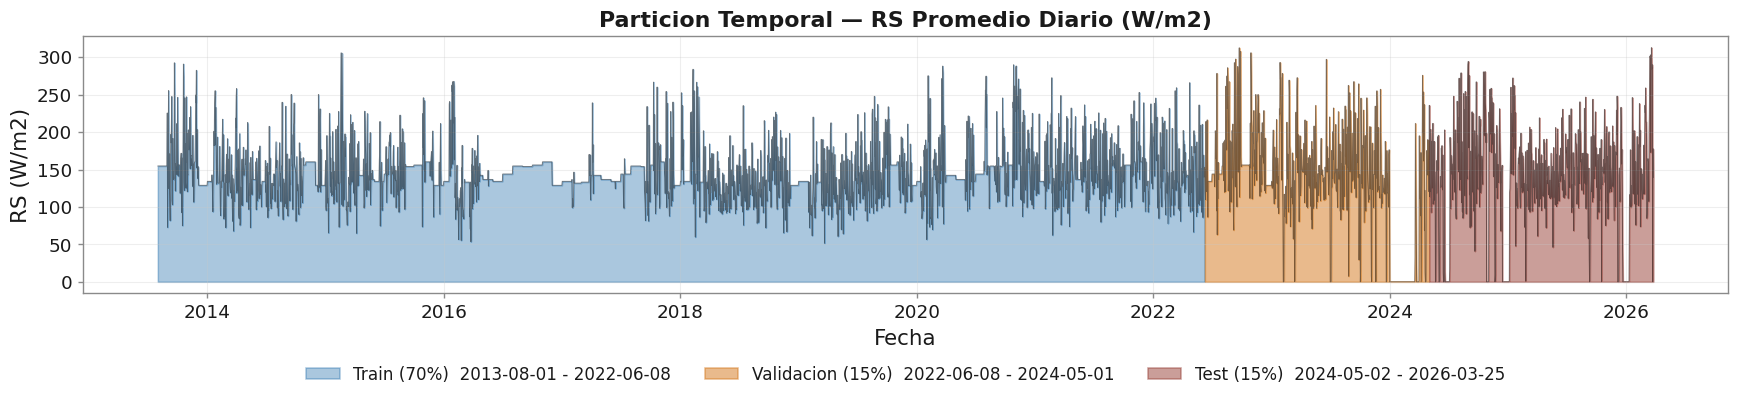

Guardado: fig_04a_particion_temporal.svg


In [ ]:
# Visualizar particion temporal
fig, ax = plt.subplots(figsize=(16, 4))
rs_d   = df['RS'].resample('D').mean()
fechas = rs_d.index
n_d_tr = int(len(rs_d) * TRAIN_RATIO)
n_d_va = int(len(rs_d) * VAL_RATIO)

ax.fill_between(fechas[:n_d_tr], rs_d.values[:n_d_tr], alpha=0.35,
                color=C_AZUL,
                label=f'Train ({TRAIN_RATIO:.0%})  '
                      f'{df_model.index[0].date()} - {df_model.index[idx_train_end-1].date()}')
ax.fill_between(fechas[n_d_tr:n_d_tr+n_d_va],
                rs_d.values[n_d_tr:n_d_tr+n_d_va], alpha=0.5,
                color=C_AMBAR,
                label=f'Validacion ({VAL_RATIO:.0%})  '
                      f'{df_model.index[idx_train_end].date()} - {df_model.index[idx_val_end-1].date()}')
ax.fill_between(fechas[n_d_tr+n_d_va:],
                rs_d.values[n_d_tr+n_d_va:], alpha=0.5,
                color=C_TEJA,
                label=f'Test ({TEST_RATIO:.0%})  '
                      f'{df_model.index[idx_val_end].date()} - {df_model.index[-1].date()}')
ax.plot(fechas, rs_d.values, color=C_TEXTO, lw=0.6, alpha=0.5)
ax.set_title('Particion Temporal — RS Promedio Diario (W/m2)')
ax.set_ylabel('RS (W/m2)')
ax.set_xlabel('Fecha')
ax.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, -0.22),
          ncol=3, frameon=False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
guardar_figura(plt.gcf(), 'fig_04a_particion_temporal')
plt.show()
print('Guardado: fig_04a_particion_temporal.svg')

In [ ]:
# 4. Clase InformerDataset — Dataset dinamico de PyTorch
#
# Esta clase implementa la interfaz Dataset de PyTorch.
# No almacena las ventanas en memoria: cada vez que el DataLoader
# solicita el item i, se extraen los slices correspondientes del
# array data_norm (91 MB en RAM) mediante indexacion numpy.
#
# Estructura de cada muestra (indice t relativo al split):
#
#   enc_input  : data_norm[t : t+seq_len, :]           (seq_len, n_vars)
#   enc_mark   : marcas_temp[t : t+seq_len, :]         (seq_len, 4)
#   dec_input  : data_norm[t+seq_len-label_len :        (label_len+pred_len, n_vars)
#                           t+seq_len+pred_len, :]
#   dec_mark   : marcas_temp[t+seq_len-label_len :]    (label_len+pred_len, 4)
#   target     : data_norm[t+seq_len :                  (pred_len,)
#                           t+seq_len+pred_len, idx_objetivo]
#
# El decodificador recibe los ultimos label_len pasos observados
# mas pred_len pasos de relleno (zeros en la posicion objetivo),
# que es el mecanismo de generative decoding del Informer.

class InformerDataset(Dataset):
    """
    Dataset de indexacion dinamica para el modelo Informer.

    Parametros:
    -----------
    data        : np.ndarray (N, n_vars) float32 — datos normalizados
    marcas      : np.ndarray (N, 4) float32 — marcas temporales
    idx_inicio  : int — primer indice del split en data
    idx_fin     : int — ultimo indice del split en data (exclusive)
    seq_len     : int — longitud de la secuencia de entrada del encoder
    label_len   : int — longitud del prefijo conocido del decoder
    pred_len    : int — longitud del horizonte de prediccion
    idx_objetivo: int — columna de la variable objetivo en data
    """

    def __init__(self, data, marcas, idx_inicio, idx_fin,
                 seq_len, label_len, pred_len, idx_objetivo):
        self.data         = data
        self.marcas       = marcas
        self.idx_inicio   = idx_inicio
        self.seq_len      = seq_len
        self.label_len    = label_len
        self.pred_len     = pred_len
        self.idx_objetivo = idx_objetivo

        # Primer indice de data donde puede comenzar una ventana
        # (necesita seq_len pasos atras)
        self._inicio = max(idx_inicio, seq_len)

        # Ultimo indice de data donde puede comenzar una ventana
        # (necesita pred_len pasos adelante)
        self._fin    = min(idx_fin, len(data) - pred_len)

        self._len = max(0, self._fin - self._inicio)

    def __len__(self):
        return self._len

    def __getitem__(self, i):
        # Indice absoluto en data para la ventana i
        t = self._inicio + i

        # Encoder: seq_len pasos de contexto
        enc_input = self.data[t - self.seq_len : t, :]        # (seq_len, n_vars)
        enc_mark  = self.marcas[t - self.seq_len : t, :]      # (seq_len, 4)

        # Decoder: label_len pasos conocidos + pred_len pasos futuros
        # En los pasos futuros, la columna objetivo se enmascara con 0
        # (generative decoding del Informer)
        dec_start  = t - self.label_len
        dec_end    = t + self.pred_len
        dec_input  = self.data[dec_start : dec_end, :].copy() # (label_len+pred_len, n_vars)
        dec_mark   = self.marcas[dec_start : dec_end, :]      # (label_len+pred_len, 4)

        # Enmascarar el objetivo en los pasos futuros del decoder
        dec_input[self.label_len:, self.idx_objetivo] = 0.0

        # Target: solo la variable objetivo en el horizonte futuro
        target = self.data[t : t + self.pred_len, self.idx_objetivo]  # (pred_len,)

        return (
            torch.from_numpy(enc_input),   # (seq_len, n_vars)
            torch.from_numpy(enc_mark),    # (seq_len, 4)
            torch.from_numpy(dec_input),   # (label_len+pred_len, n_vars)
            torch.from_numpy(dec_mark),    # (label_len+pred_len, 4)
            torch.from_numpy(target),      # (pred_len,)
        )

print('Clase InformerDataset definida.')

Clase InformerDataset definida.


In [ ]:
# 5. Verificacion y prueba del Dataset
print('VERIFICACION DEL DATASET')
print('=' * 65)

splits_config = [
    ('train', IDX_TRAIN_INI, IDX_TRAIN_FIN),
    ('val',   IDX_VAL_INI,   IDX_VAL_FIN),
    ('test',  IDX_TEST_INI,  IDX_TEST_FIN),
]

# Instanciar datasets para cada horizonte
datasets_todos = {}

for nombre_pred, pred_len in PRED_LENS.items():
    print(f'\nHorizonte {nombre_pred} (pred_len={pred_len} = {pred_len*5/60:.1f}h):')
    datasets_todos[nombre_pred] = {}

    for split_name, i_ini, i_fin in splits_config:
        ds = InformerDataset(
            data=data_norm,
            marcas=marcas_temp,
            idx_inicio=i_ini,
            idx_fin=i_fin,
            seq_len=SEQ_LEN,
            label_len=LABEL_LEN,
            pred_len=pred_len,
            idx_objetivo=IDX_OBJETIVO
        )
        datasets_todos[nombre_pred][split_name] = ds

        # Obtener una muestra de prueba
        muestra = ds[0]
        shapes  = [t.shape for t in muestra]
        print(f'  {split_name:<6}: {len(ds):>7,} muestras  '
              f'enc={shapes[0]}  dec={shapes[2]}  target={shapes[4]}')

print()
print('Todos los datasets instanciados correctamente.')
print('RAM usada por data_norm + marcas_temp:',
      f'{(data_norm.nbytes + marcas_temp.nbytes)/1024**2:.1f} MB')
print('RAM usada por los datasets: ~0 MB adicionales (indexacion dinamica)')

VERIFICACION DEL DATASET

Horizonte 1h (pred_len=12 = 1.0h):
  train : 931,103 muestras  enc=torch.Size([288, 18])  dec=torch.Size([156, 18])  target=torch.Size([12])
  val   : 199,009 muestras  enc=torch.Size([288, 18])  dec=torch.Size([156, 18])  target=torch.Size([12])
  test  : 198,996 muestras  enc=torch.Size([288, 18])  dec=torch.Size([156, 18])  target=torch.Size([12])

Horizonte 3h (pred_len=36 = 3.0h):
  train : 931,103 muestras  enc=torch.Size([288, 18])  dec=torch.Size([180, 18])  target=torch.Size([36])
  val   : 199,009 muestras  enc=torch.Size([288, 18])  dec=torch.Size([180, 18])  target=torch.Size([36])
  test  : 198,972 muestras  enc=torch.Size([288, 18])  dec=torch.Size([180, 18])  target=torch.Size([36])

Horizonte 6h (pred_len=72 = 6.0h):
  train : 931,103 muestras  enc=torch.Size([288, 18])  dec=torch.Size([216, 18])  target=torch.Size([72])
  val   : 199,009 muestras  enc=torch.Size([288, 18])  dec=torch.Size([216, 18])  target=torch.Size([72])
  test  : 198,936 m

In [ ]:
# Prueba de velocidad del DataLoader (simula un epoch de entrenamiento)
# Confirma que la indexacion dinamica es lo suficientemente rapida

import time

ds_prueba = datasets_todos['1h']['train']
dl_prueba = DataLoader(
    ds_prueba,
    batch_size=64,
    shuffle=True,
    num_workers=0,   # En Colab usar 0 para evitar problemas de multiprocessing
    pin_memory=False
)

print('Probando velocidad del DataLoader (100 batches de 64 muestras)...')
t0       = time.time()
n_batches = 0
for batch in dl_prueba:
    enc, enc_m, dec, dec_m, tgt = batch
    n_batches += 1
    if n_batches >= 100:
        break

t1 = time.time()
print(f'  100 batches procesados en {t1-t0:.2f}s')
print(f'  Velocidad: {100/(t1-t0):.1f} batches/s')
print(f'  Shape enc  : {enc.shape}   dtype: {enc.dtype}')
print(f'  Shape dec  : {dec.shape}   dtype: {dec.dtype}')
print(f'  Shape tgt  : {tgt.shape}   dtype: {tgt.dtype}')

del dl_prueba
gc.collect()

Probando velocidad del DataLoader (100 batches de 64 muestras)...
  100 batches procesados en 0.64s
  Velocidad: 157.4 batches/s
  Shape enc  : torch.Size([64, 288, 18])   dtype: torch.float32
  Shape dec  : torch.Size([64, 156, 18])   dtype: torch.float32
  Shape tgt  : torch.Size([64, 12])   dtype: torch.float32


2018

In [ ]:
# 6. Guardado de artefactos
#
# Se guardan:
# - data_norm.npy   : array normalizado (91 MB) — fuente de las ventanas
# - marcas_temp.npy : marcas temporales (20 MB)
# - scaler_full.pkl : scaler de todas las variables
# - scaler_rs.pkl   : scaler de RS para desnormalizar predicciones
# - config_fe.pkl   : configuracion completa del pipeline
#
# En el Notebook 05 se reconstruyen los datasets con:
#   data_norm   = np.load('data_norm.npy')
#   marcas_temp = np.load('marcas_temp.npy')
#   ds_train    = InformerDataset(data_norm, marcas_temp, ...)

print('Guardando artefactos...')

np.save(os.path.join(RUTA_ARRAYS, 'data_norm.npy'),    data_norm)
np.save(os.path.join(RUTA_ARRAYS, 'marcas_temp.npy'),  marcas_temp)

# Marcas de tiempo exactas de cada fila — anadido en la revision.
# El cuaderno 06 las necesita para dos cosas: anular la prediccion fuera de la
# franja diurna, y agrupar las metricas por trimestre. Reconstruirlas a partir
# de marcas_temp seria imposible, porque alli no viaja el anio.
np.save(os.path.join(RUTA_ARRAYS, 'timestamps.npy'),
        df_model.index.values.astype('datetime64[ns]'))

# Marca de origen, fila a fila: True = medido por el sensor, False = rellenado.
np.save(os.path.join(RUTA_ARRAYS, 'observado.npy'), OBSERVADO)

_h = df_model.index.hour
_d = (_h >= 6) & (_h <= 18)
print()
print('PROPORCION DE PUNTOS MEDIDOS POR BLOQUE (franja diurna)')
print('=' * 62)
for _nom, _a, _b in [('Entrenamiento', IDX_TRAIN_INI, IDX_TRAIN_FIN),
                     ('Validacion',    IDX_VAL_INI,   IDX_VAL_FIN),
                     ('Prueba',        IDX_TEST_INI,  IDX_TEST_FIN)]:
    _m = np.zeros(len(df_model), dtype=bool); _m[_a:_b] = True
    _sel = _m & _d
    _pct = 100.0 * OBSERVADO[_sel].mean() if _sel.sum() else float('nan')
    print(f'  {_nom:<14} {OBSERVADO[_sel].sum():>9,} de {_sel.sum():>9,} medidos  ({_pct:5.1f} %)')
print()
print('  El porcentaje del bloque de PRUEBA es el que importa: es la fraccion de')
print('  los objetivos contra los que se medira el modelo que si fueron medidos.')

with open(os.path.join(RUTA_ARRAYS, 'scaler_full.pkl'), 'wb') as f:
    pickle.dump(scaler_full, f)
with open(os.path.join(RUTA_ARRAYS, 'scaler_rs.pkl'), 'wb') as f:
    pickle.dump(scaler_rs, f)

config = {
    'vars_entrada'    : VARS_ENTRADA,
    'var_objetivo'    : VAR_OBJETIVO,
    'idx_objetivo'    : IDX_OBJETIVO,
    'n_vars'          : N_VARS,
    'seq_len'         : SEQ_LEN,
    'label_len'       : LABEL_LEN,
    'pred_lens'       : PRED_LENS,
    'train_ratio'     : TRAIN_RATIO,
    'val_ratio'       : VAL_RATIO,
    'test_ratio'      : TEST_RATIO,
    'n_total'         : N,
    'n_train'         : n_train,
    'n_val'           : n_val,
    'n_test'          : n_test,
    'idx_train_end'   : idx_train_end,
    'idx_val_end'     : idx_val_end,
    # --- Indices con embargo, anadidos en la revision --------------------
    'embargo'         : EMBARGO,
    'idx_train_ini'   : IDX_TRAIN_INI,
    'idx_train_fin'   : IDX_TRAIN_FIN,
    'idx_val_ini'     : IDX_VAL_INI,
    'idx_val_fin'     : IDX_VAL_FIN,
    'idx_test_ini'    : IDX_TEST_INI,
    'idx_test_fin'    : IDX_TEST_FIN,
    'fecha_inicio'    : str(df_model.index[0]),
    'freq_min'        : 5,
    'tecnica_imputacion': TECNICA,
    # Fechas de los limites REALES de cada bloque — corregido en la revision.
    # Antes 'fecha_val_ini' apuntaba a idx_train_end, que con el embargo es el
    # primer paso de la banda descartada, no el primero de validacion.
    'fecha_train_ini' : str(df_model.index[IDX_TRAIN_INI].date()),
    'fecha_train_fin' : str(df_model.index[IDX_TRAIN_FIN-1].date()),
    'fecha_val_ini'   : str(df_model.index[IDX_VAL_INI].date()),
    'fecha_val_fin'   : str(df_model.index[IDX_VAL_FIN-1].date()),
    'fecha_test_ini'  : str(df_model.index[IDX_TEST_INI].date()),
    'fecha_test_fin'  : str(df_model.index[IDX_TEST_FIN-1].date()),
    'fecha_embargo1'  : (str(df_model.index[IDX_TRAIN_FIN].date()),
                         str(df_model.index[IDX_VAL_INI-1].date())),
    'fecha_embargo2'  : (str(df_model.index[IDX_VAL_FIN].date()),
                         str(df_model.index[IDX_TEST_INI-1].date())),
    'n_muestras_train': {k: len(v['train']) for k, v in datasets_todos.items()},
    'n_muestras_val'  : {k: len(v['val'])   for k, v in datasets_todos.items()},
    'n_muestras_test' : {k: len(v['test'])  for k, v in datasets_todos.items()},
}
with open(os.path.join(RUTA_ARRAYS, 'config_fe.pkl'), 'wb') as f:
    pickle.dump(config, f)

print('Artefactos guardados en datos/arrays/:')
for fname in ['data_norm.npy','marcas_temp.npy','scaler_full.pkl',
              'scaler_rs.pkl','config_fe.pkl']:
    ruta_f = os.path.join(RUTA_ARRAYS, fname)
    tam    = os.path.getsize(ruta_f) / 1024**2
    print(f'  {fname:<25} {tam:.2f} MB')

Guardando artefactos...

PROPORCION DE PUNTOS MEDIDOS POR BLOQUE (franja diurna)
  Entrenamiento    293,382 de   504,504 medidos  ( 58.2 %)
  Validacion        95,121 de   107,796 medidos  ( 88.2 %)
  Prueba           107,796 de   107,796 medidos  (100.0 %)

  El porcentaje del bloque de PRUEBA es el que importa: es la fraccion de
  los objetivos contra los que se medira el modelo que si fueron medidos.
Artefactos guardados en datos/arrays/:
  data_norm.npy             91.36 MB
  marcas_temp.npy           20.30 MB
  scaler_full.pkl           0.00 MB
  scaler_rs.pkl             0.00 MB
  config_fe.pkl             0.00 MB


  Figura guardada: fig_04b_ejemplo_ventana.png, .svg y .pdf


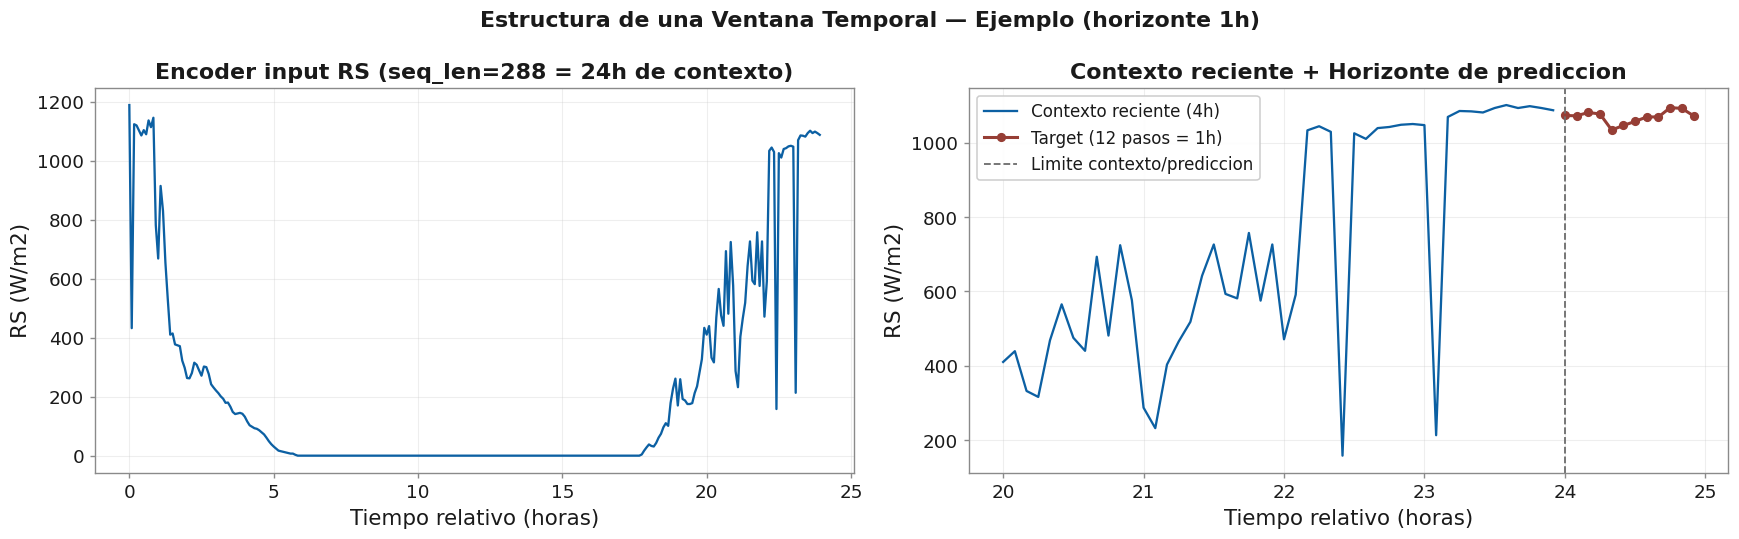

Guardado: fig_04b_ejemplo_ventana.svg


In [ ]:
# 7. Visualizacion: ejemplo de ventana y distribucion de targets

# Encontrar la ventana con mayor RS promedio en el target del train 1h
ds_1h_train = datasets_todos['1h']['train']

# Muestrear 5000 ventanas para encontrar la de mayor RS (no cargar todo)
n_muestra = min(5000, len(ds_1h_train))
indices   = np.random.choice(len(ds_1h_train), n_muestra, replace=False)
max_rs    = -1
idx_alto  = 0
for idx in indices:
    _, _, _, _, tgt = ds_1h_train[idx]
    media = tgt.mean().item()
    if media > max_rs:
        max_rs   = media
        idx_alto = idx

enc_ej, _, dec_ej, _, tgt_ej = ds_1h_train[idx_alto]

# Desnormalizar RS para visualizacion
rs_enc  = scaler_rs.inverse_transform(
    enc_ej[:, IDX_OBJETIVO].numpy().reshape(-1,1)
).flatten()
rs_pred = scaler_rs.inverse_transform(
    tgt_ej.numpy().reshape(-1,1)
).flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Estructura de una Ventana Temporal — Ejemplo (horizonte 1h)',
             fontsize=14.5, fontweight='bold')

t_enc  = np.arange(SEQ_LEN) * 5 / 60
t_pred = (SEQ_LEN + np.arange(PRED_LENS['1h'])) * 5 / 60

axes[0].plot(t_enc, rs_enc, color=C_AZUL, lw=1.5)
axes[0].set_title(f'Encoder input RS (seq_len={SEQ_LEN} = 24h de contexto)')
axes[0].set_xlabel('Tiempo relativo (horas)')
axes[0].set_ylabel('RS (W/m2)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_enc[-48:], rs_enc[-48:], color=C_AZUL, lw=1.5,
             label='Contexto reciente (4h)')
axes[1].plot(t_pred, rs_pred, color=C_TEJA, lw=2, marker='o', ms=5,
             label=f'Target ({PRED_LENS["1h"]} pasos = 1h)')
axes[1].axvline(SEQ_LEN*5/60, color=C_GRIS, lw=1.2, ls='--',
                label='Limite contexto/prediccion')
axes[1].set_title('Contexto reciente + Horizonte de prediccion')
axes[1].set_xlabel('Tiempo relativo (horas)')
axes[1].set_ylabel('RS (W/m2)')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
guardar_figura(plt.gcf(), 'fig_04b_ejemplo_ventana')
plt.show()
print('Guardado: fig_04b_ejemplo_ventana.svg')

  Figura guardada: fig_04c_distribucion_targets.png, .svg y .pdf


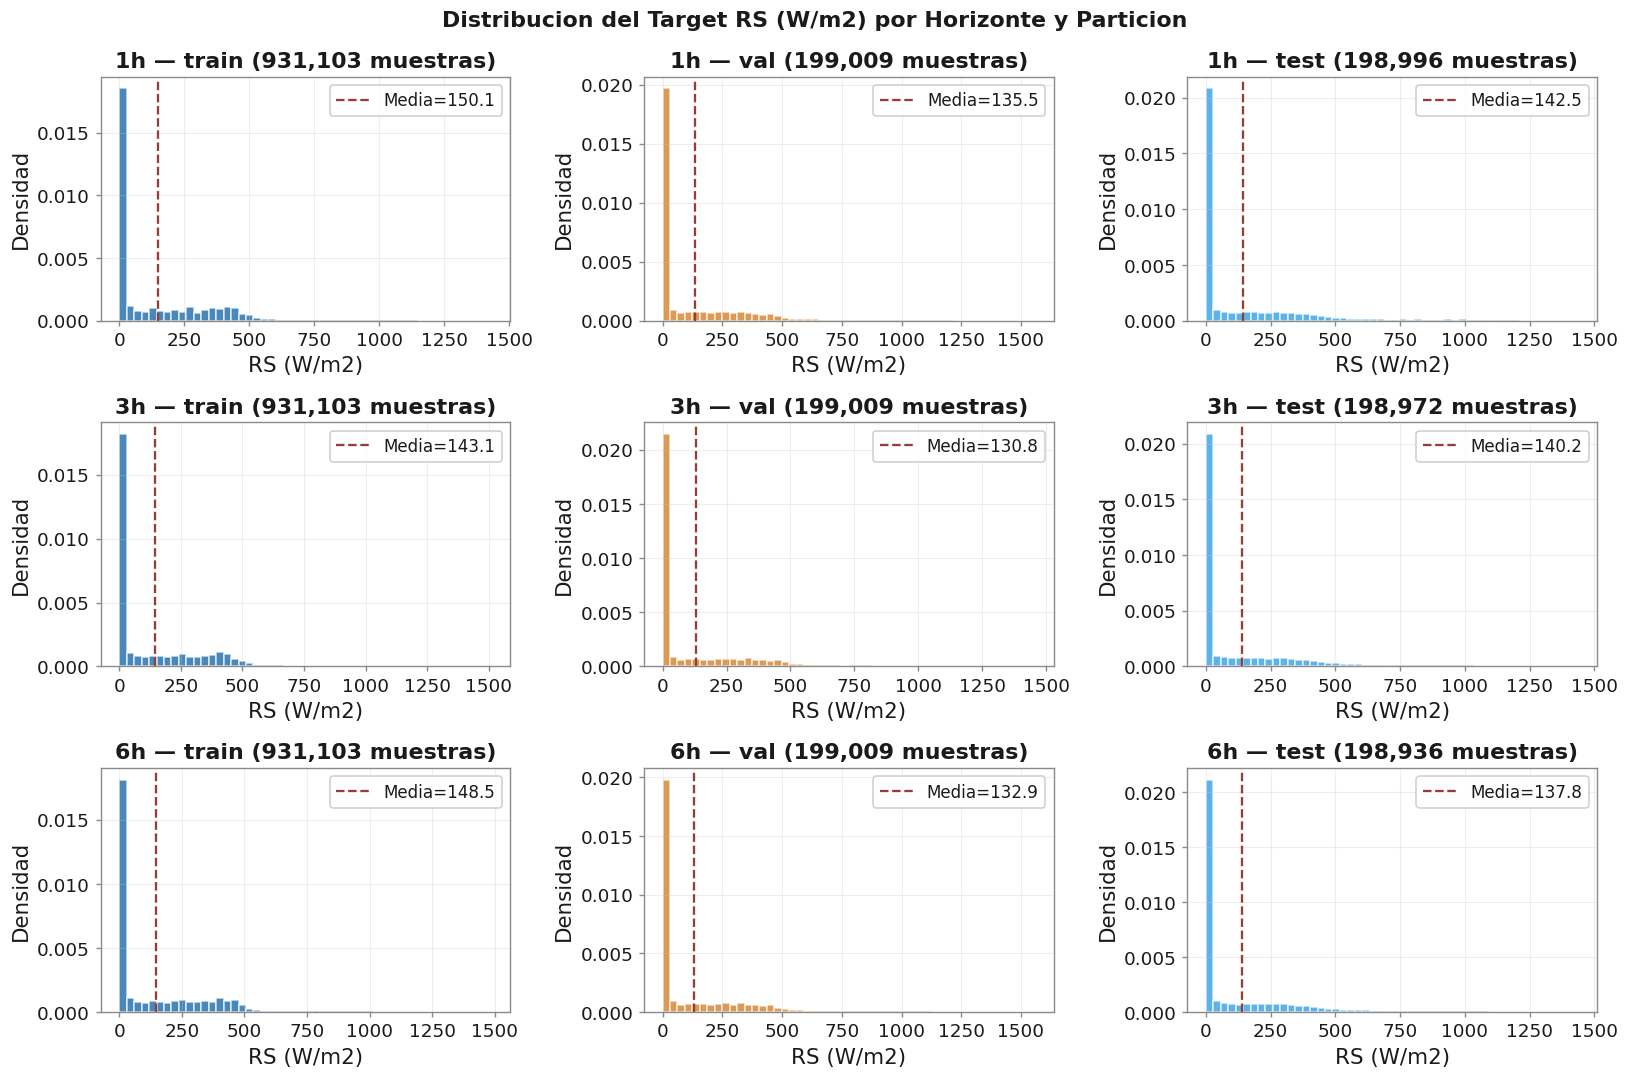

Guardado: fig_04c_distribucion_targets.svg


In [ ]:
# Distribucion del target por horizonte y split
# Se muestrean 10,000 ventanas por celda para no agotar RAM
N_MUESTRA_VIZ = 10_000

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Distribucion del Target RS (W/m2) por Horizonte y Particion',
             fontsize=14.5, fontweight='bold')

for i, nombre_pred in enumerate(PRED_LENS):
    for j, split_name in enumerate(['train', 'val', 'test']):
        ax = axes[i, j]
        ds = datasets_todos[nombre_pred][split_name]
        n  = len(ds)
        idx_m = np.random.choice(n, min(N_MUESTRA_VIZ, n), replace=False)

        targets = np.concatenate([
            ds[int(k)][4].numpy() for k in idx_m
        ])
        y_real = scaler_rs.inverse_transform(
            targets.reshape(-1,1)
        ).flatten()

        ax.hist(y_real, bins=50, density=True, alpha=0.75,
                color=[C_AZUL, C_AMBAR, C_CELESTE][j], edgecolor='white')
        ax.axvline(y_real.mean(), color=C_TEJA, lw=1.5, ls='--',
                   label=f'Media={y_real.mean():.1f}')
        ax.set_title(f'{nombre_pred} — {split_name} ({n:,} muestras)')
        ax.set_xlabel('RS (W/m2)')
        ax.set_ylabel('Densidad')
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
guardar_figura(plt.gcf(), 'fig_04c_distribucion_targets')
plt.show()
print('Guardado: fig_04c_distribucion_targets.svg')

In [ ]:
# 8. Resumen final
print('=' * 70)
print('RESUMEN — NOTEBOOK 04 FEATURE ENGINEERING')
print('=' * 70)
print(f'''
DATASET DE ENTRADA
  Archivo    : dataset_final_interpolacion.csv (T1)
  Registros  : {N:,}  |  Variables: {N_VARS}
  Periodo    : {df_model.index[0].date()} -> {df_model.index[-1].date()}

VARIABLES ({N_VARS})
  Objetivo   : RS (posicion {IDX_OBJETIVO} en el vector)
  Temporales : sin/cos hora, sin/cos dia_anio, sin/cos mes
  NASA POWER : ALLSKY, CLRSKY, T2M, RH2M, PRECTOTCORR,
               WS10M, WD10M_u, WD10M_v, PS, SZA, KT
  Nota       : WD10M transformado a componentes u/v (variable circular)

NORMALIZACION
  Metodo     : MinMaxScaler [0, 1]
  Ajuste     : Solo datos de entrenamiento
  data_norm  : {data_norm.shape}  {data_norm.nbytes/1024**2:.1f} MB en RAM

PARTICION
  Train (70%): {n_train:>9,} -> {df_model.index[idx_train_end-1].date()}
  Val   (15%): {n_val:>9,} -> {df_model.index[idx_val_end-1].date()}
  Test  (15%): {n_test:>9,} -> {df_model.index[-1].date()}

VENTANAS (indexacion dinamica — sin arrays estaticos en memoria)
  seq_len    : {SEQ_LEN} pasos = 24h de contexto
  label_len  : {LABEL_LEN} pasos = 12h (inicio decodificador Informer)
''')

for nombre_pred, pred_len in PRED_LENS.items():
    n_tr = len(datasets_todos[nombre_pred]['train'])
    n_va = len(datasets_todos[nombre_pred]['val'])
    n_te = len(datasets_todos[nombre_pred]['test'])
    print(f'  Horizonte {nombre_pred} (pred_len={pred_len} pasos = {pred_len*5/60:.1f}h):')
    print(f'    Train: {n_tr:>7,}  Val: {n_va:>6,}  Test: {n_te:>6,}  muestras')

print()
print('Artefactos guardados en datos/arrays/:')
for fname in sorted(os.listdir(RUTA_ARRAYS)):
    tam = os.path.getsize(os.path.join(RUTA_ARRAYS, fname)) / 1024**2
    print(f'  {fname:<30} {tam:.2f} MB')

print()
print('Notebook 04 completado.')
print('Siguientes:')
print('  05_modelo_informer.ipynb')
print('  06_modelos_baseline_lstm_gru.ipynb')

RESUMEN — NOTEBOOK 04 FEATURE ENGINEERING

DATASET DE ENTRADA
  Archivo    : dataset_final_interpolacion.csv (T1)
  Registros  : 1,330,560  |  Variables: 18
  Periodo    : 2013-08-01 -> 2026-03-25

VARIABLES (18)
  Objetivo   : RS (posicion 0 en el vector)
  Temporales : sin/cos hora, sin/cos dia_anio, sin/cos mes
  NASA POWER : ALLSKY, CLRSKY, T2M, RH2M, PRECTOTCORR,
               WS10M, WD10M_u, WD10M_v, PS, SZA, KT
  Nota       : WD10M transformado a componentes u/v (variable circular)

NORMALIZACION
  Metodo     : MinMaxScaler [0, 1]
  Ajuste     : Solo datos de entrenamiento
  data_norm  : (1330560, 18)  91.4 MB en RAM

PARTICION
  Train (70%):   931,391 -> 2022-06-08
  Val   (15%):   199,009 -> 2024-05-01
  Test  (15%):   199,008 -> 2026-03-25

VENTANAS (indexacion dinamica — sin arrays estaticos en memoria)
  seq_len    : 288 pasos = 24h de contexto
  label_len  : 144 pasos = 12h (inicio decodificador Informer)

  Horizonte 1h (pred_len=12 pasos = 1.0h):
    Train: 931,103  Val